In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report,confusion_matrix,roc_curve

In [2]:
features,target=make_classification(n_samples=12000,n_features=30,n_informative=12,n_redundant=8,weights=[0.985,0.015],flip_y=0.003,class_sep=1.25,random_state=42)
fraud=pd.DataFrame(features,columns=['V'+str(i) for i in range(1,31)])
fraud['Amount']=np.exp(np.clip(fraud['V1']+np.random.default_rng(42).normal(3,1.2,len(fraud)),0,8))
fraud['Class']=target
fraud.to_csv('credit_card_fraud_data.csv',index=False)
print(fraud.shape)
print(fraud.Class.value_counts())
print(fraud.isna().sum().sum())

(12000, 32)
Class
0    11803
1      197
Name: count, dtype: int64
0


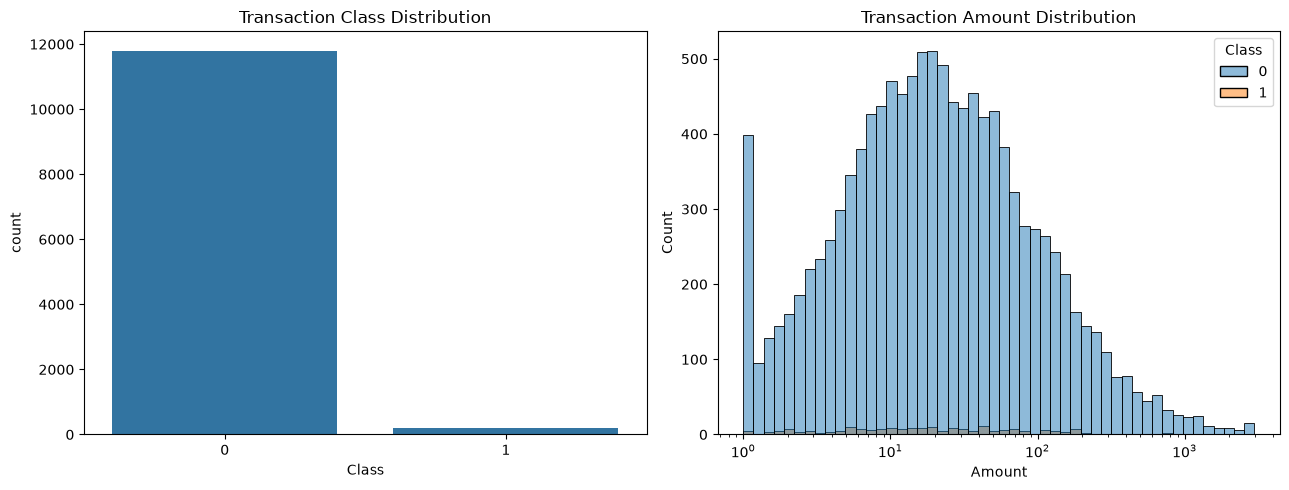

In [3]:
fig,axes=plt.subplots(1,2,figsize=(13,5))
sns.countplot(data=fraud,x='Class',ax=axes[0])
axes[0].set_title('Transaction Class Distribution')
sns.histplot(data=fraud,x='Amount',hue='Class',bins=50,log_scale=True,ax=axes[1])
axes[1].set_title('Transaction Amount Distribution')
plt.tight_layout()
plt.show()

In [4]:
X=fraud.drop(columns='Class')
y=fraud.Class
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,stratify=y,random_state=42)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
train_frame=pd.DataFrame(X_train_scaled,columns=X.columns)
train_frame['Class']=y_train.to_numpy()
majority=train_frame[train_frame.Class==0]
minority=train_frame[train_frame.Class==1]
minority_oversampled=resample(minority,replace=True,n_samples=len(majority),random_state=42)
balanced_train=pd.concat([majority,minority_oversampled]).sample(frac=1,random_state=42)
X_balanced=balanced_train.drop(columns='Class')
y_balanced=balanced_train.Class
print(pd.Series(y_balanced).value_counts())

Class
1    8852
0    8852
Name: count, dtype: int64


In [7]:
from sklearn.calibration import CalibratedClassifierCV

In [10]:
try:
 from xgboost import XGBClassifier
 xgb_model=XGBClassifier(n_estimators=250,max_depth=4,learning_rate=0.05,subsample=0.85,colsample_bytree=0.85,eval_metric='logloss',random_state=42)
 xgb_label='XGBoost'
except ImportError:
 xgb_model=HistGradientBoostingClassifier(max_iter=250,max_leaf_nodes=31,learning_rate=0.05,random_state=42)
 xgb_label='XGBoost-Compatible Gradient Boosting'
models={'Logistic Regression':LogisticRegression(max_iter=2000,class_weight='balanced',random_state=42),'Random Forest':RandomForestClassifier(n_estimators=300,class_weight='balanced',random_state=42,n_jobs=-1),'SVM':CalibratedClassifierCV(SVC(kernel='rbf',class_weight='balanced',random_state=42),ensemble=False),'XGBoost':xgb_model}
for name,model in models.items():
 model.fit(X_balanced,y_balanced)
print(xgb_label)

XGBoost


In [11]:
results=[]
predictions={}
probabilities={}
for name,model in models.items():
 predicted=model.predict(X_test_scaled)
 probability=model.predict_proba(X_test_scaled)[:,1]
 predictions[name]=predicted
 probabilities[name]=probability
 results.append([name,accuracy_score(y_test,predicted),precision_score(y_test,predicted,zero_division=0),recall_score(y_test,predicted,zero_division=0),f1_score(y_test,predicted,zero_division=0),roc_auc_score(y_test,probability)])
results=pd.DataFrame(results,columns=['Model','Accuracy','Precision','Recall','F1-Score','ROC-AUC']).sort_values('ROC-AUC',ascending=False)
print(results)
print(classification_report(y_test,predictions[results.iloc[0].Model],zero_division=0))

C:\Users\sham3\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\sham3\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\sham3\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\sham3\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\sham3\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\uti

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
1        Random Forest  0.988000   1.000000  0.265306  0.419355  0.955211
2                  SVM  0.992667   1.000000  0.551020  0.710526  0.945179
3              XGBoost  0.991667   0.760870  0.714286  0.736842  0.932745
0  Logistic Regression  0.885000   0.108466  0.836735  0.192037  0.915504
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2951
           1       1.00      0.27      0.42        49

    accuracy                           0.99      3000
   macro avg       0.99      0.63      0.71      3000
weighted avg       0.99      0.99      0.98      3000



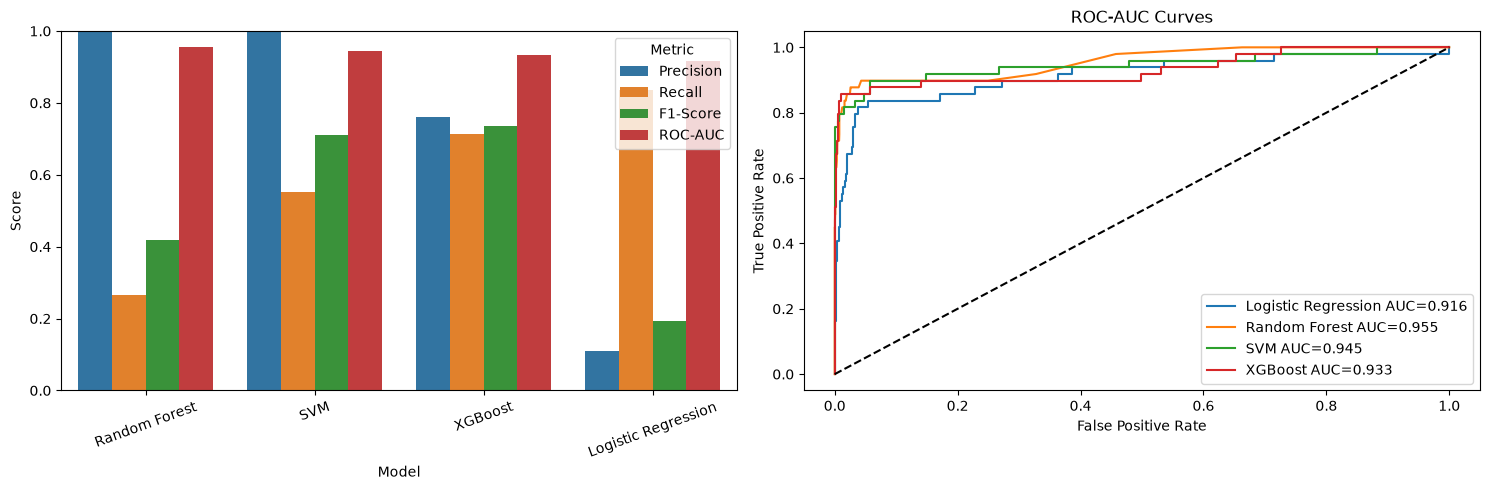

In [12]:
fig,axes=plt.subplots(1,2,figsize=(15,5))
metric_plot=results.melt(id_vars='Model',value_vars=['Precision','Recall','F1-Score','ROC-AUC'],var_name='Metric',value_name='Score')
sns.barplot(data=metric_plot,x='Model',y='Score',hue='Metric',ax=axes[0])
axes[0].tick_params(axis='x',rotation=20)
axes[0].set_ylim(0,1)
for name,probability in probabilities.items():
 fpr,tpr,_=roc_curve(y_test,probability)
 axes[1].plot(fpr,tpr,label=name+' AUC='+str(round(roc_auc_score(y_test,probability),3)))
axes[1].plot([0,1],[0,1],'k--')
axes[1].set(xlabel='False Positive Rate',ylabel='True Positive Rate',title='ROC-AUC Curves')
axes[1].legend()
plt.tight_layout()
plt.show()

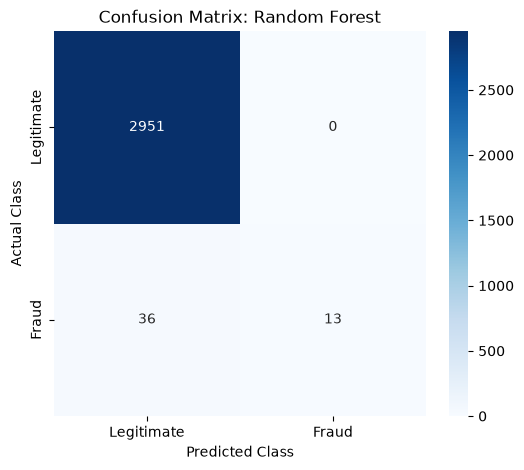

Best model: Random Forest
Best ROC-AUC: 0.9552


In [13]:
best_model=results.iloc[0].Model
cm=confusion_matrix(y_test,predictions[best_model])
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Legitimate','Fraud'],yticklabels=['Legitimate','Fraud'])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix: '+best_model)
plt.show()
print('Best model:',best_model)
print('Best ROC-AUC:',round(results.iloc[0]['ROC-AUC'],4))